## Student Performance Indicator

### Life Cycle Of Machine Learning Project

1. Understanding the Problem Statement
2. Data Collection
3. Data Checks perform
4. Exploratory Data Analysis
5. Data Preprocessing
6. Model training
7. Choose Best Model

### 1. Problem Statement

* This project understand how the student's performance is affected by other variables such as Gender, Ethnicity, Parental Level of Education, Lunch and Test Preparation Course.

### 2. Data Collection

* Dataset Source: [Students Performance in Exams](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)


### 2.1 Import Data And required Libraries

```python


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('data/stud.csv')

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### 3. Data Checks perform

* missing values
* duplicate values
* data types
* Number of Unique values in each column
* statistical measures
* Various categories present in the different categorical columns

### 3.1 Missing values


In [5]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

**No missing values** in the dataset.

### 3.2 Duplicate values

In [6]:
df.duplicated().sum()

0

**No duplicate values** in the dataset.

### 3.3 Data types

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [8]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']

title = "Numeric and Categorical Features"
width = max(60, len(title) + 8)
print("\n" + "=" * width)
print(title.upper().center(width))
print("=" * width)
print("Numeric Features :", end=' ')
print(len(numeric_features), end='\n')
print("Categorical Features :", end=' ')
print(len(categorical_features))


              NUMERIC AND CATEGORICAL FEATURES              
Numeric Features : 3
Categorical Features : 5


### 3.4 Number of Unique values in each column

In [9]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

### 3.5 Statistical Measures

In [10]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


**Inside Statistical Measures**

* Mean: 66.089 - 68.054
* Standard Deviation: 14.163 - 15.195
    * Math: 0 - 100
    * Reading: 17 - 100
    * Writing: 10 - 100

### 3.7 Exploring Data 

In [11]:
title = "Unique Values in Categorical Columns"
width = max(60, len(title) + 8)
print("\n" + "=" * width)
print(title.upper().center(width))
print("=" * width)

print("Gender :", end=' ')
print(df['gender'].unique(), end='\n')

print('Race Ethnicity :', end=' ')
print(df['race_ethnicity'].unique())

print('Parental Education :', end=' ')
print(df['parental_level_of_education'].unique())

print('Lunch :', end=' ')
print(df['lunch'].unique())

print('Test Preparation Course :', end=' ')
print(df['test_preparation_course'].unique())


            UNIQUE VALUES IN CATEGORICAL COLUMNS            
Gender : ['female' 'male']
Race Ethnicity : ['group B' 'group C' 'group A' 'group D' 'group E']
Parental Education : ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Lunch : ['standard' 'free/reduced']
Test Preparation Course : ['none' 'completed']


### 4. Feature Engineering
* total_score
* average_score
* grade

> pass Mark 33

In [12]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average_score'] = df['total_score'] / 3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [13]:
math_full = df[df['math_score'] == 100]['average_score'].count()
writing_full = df[df['writing_score'] == 100]['average_score'].count()
reading_full = df[df['reading_score'] == 100]['average_score'].count()

title = "Max Scores Achieved"
width = max(60, len(title) + 8)
print("\n" + "=" * width)
print(title.upper().center(width))
print("=" * width)

print("Number of Students with Full Math Score:", end=' ')
print(math_full, end='\n')
print("Number of Students with Full Writing Score:", end=' ')
print(writing_full, end='\n')
print("Number of Students with Full Reading Score:", end=' ')
print(reading_full)


                    MAX SCORES ACHIEVED                     
Number of Students with Full Math Score: 7
Number of Students with Full Writing Score: 14
Number of Students with Full Reading Score: 17


In [15]:
math_less = df[df['math_score'] < 33]['average_score'].count()
writing_less = df[df['writing_score'] < 33]['average_score'].count()
reading_less = df[df['reading_score'] < 33]['average_score'].count()

title = "Scores Below Passing Mark"
width = max(60, len(title) + 8)
print("\n" + "=" * width)
print(title.upper().center(width))
print("=" * width)

print("Number of Students with Math Score Below pass mark:", end=' ')
print(math_less, end='\n')
print("Number of Students with Writing Score Below pass mark:", end=' ')
print(writing_less, end='\n')
print("Number of Students with Reading Score Below pass mark:", end=' ')
print(reading_less)


                 SCORES BELOW PASSING MARK                  
Number of Students with Math Score Below pass mark: 19
Number of Students with Writing Score Below pass mark: 12
Number of Students with Reading Score Below pass mark: 11


### 5. Data Visualization

- From Feature Engineering we have created new features `total_score`, `average_score`
- Student West Performance in `Math`
- Student Bast Performance in `Reading`

### 5.1 Visualize distribution by Gender

- Histogram
- Kernel Density Estimate (KDE) Plot

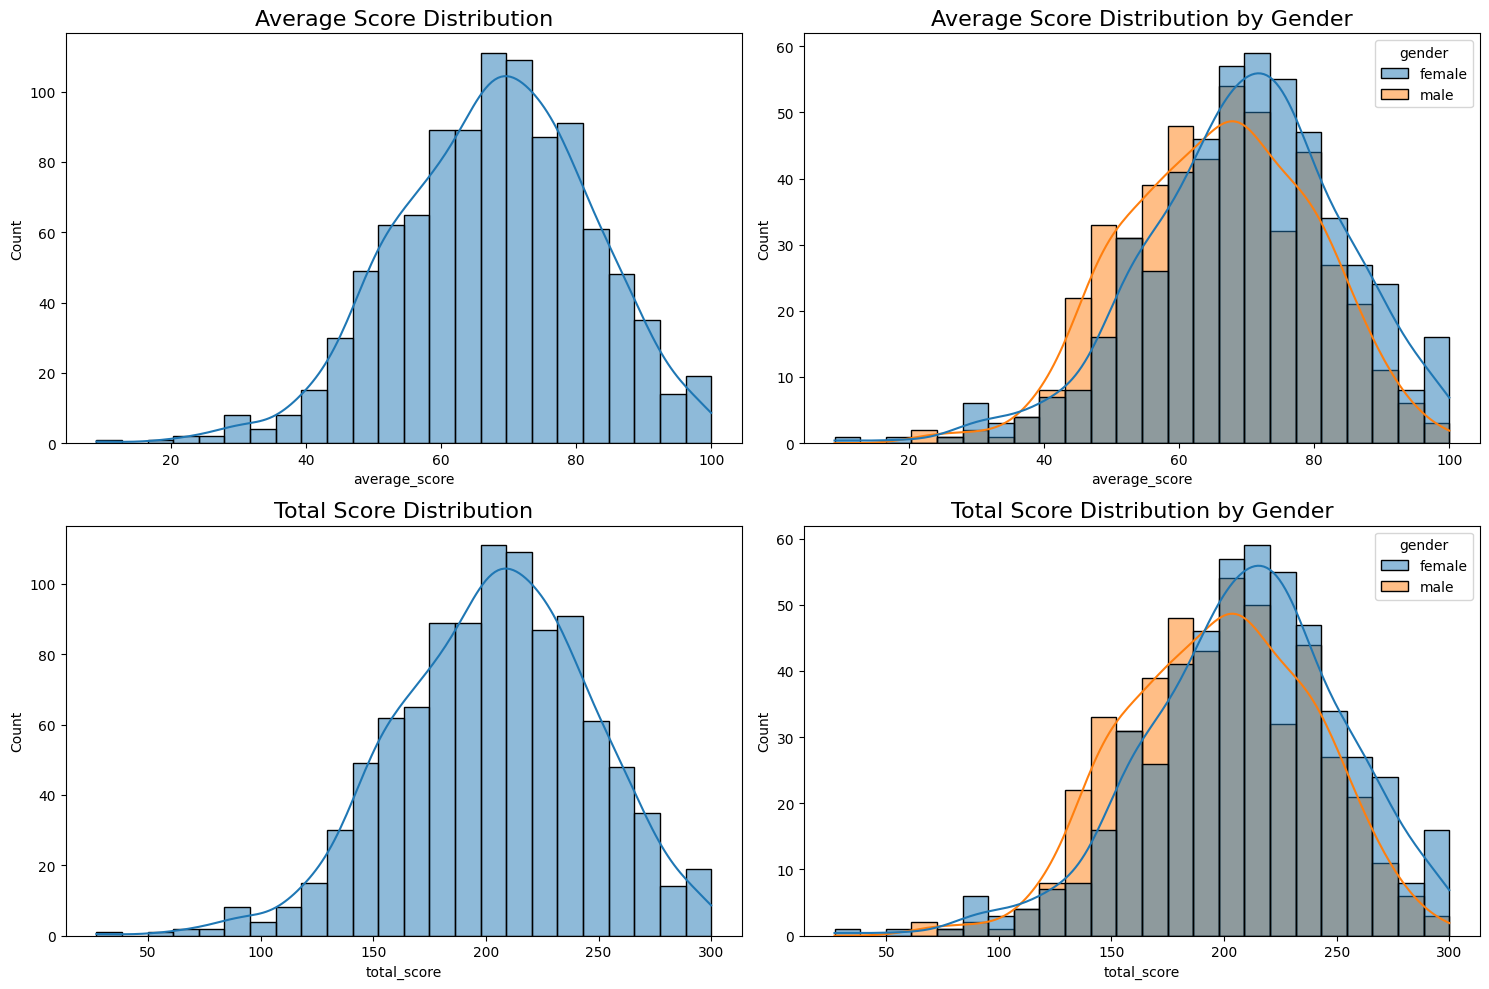

In [35]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
plt.subplot(2, 2, 1)
plt.title('Average Score Distribution', size=16)
sns.histplot(data=df, x='average_score',  kde=True)
plt.subplot(2, 2, 2)
plt.title('Average Score Distribution by Gender', size=16)
sns.histplot(data=df, x='average_score', kde=True, hue='gender')

plt.subplot(2, 2, 3)
plt.title('Total Score Distribution', size=16)
sns.histplot(data=df, x='total_score', kde=True)
plt.subplot(2, 2, 4)
plt.title('Total Score Distribution by Gender', size=16)
sns.histplot(data=df, x='total_score', kde=True, hue='gender')
plt.tight_layout()
plt.show()

> Female students have higher average and total scores than male students.

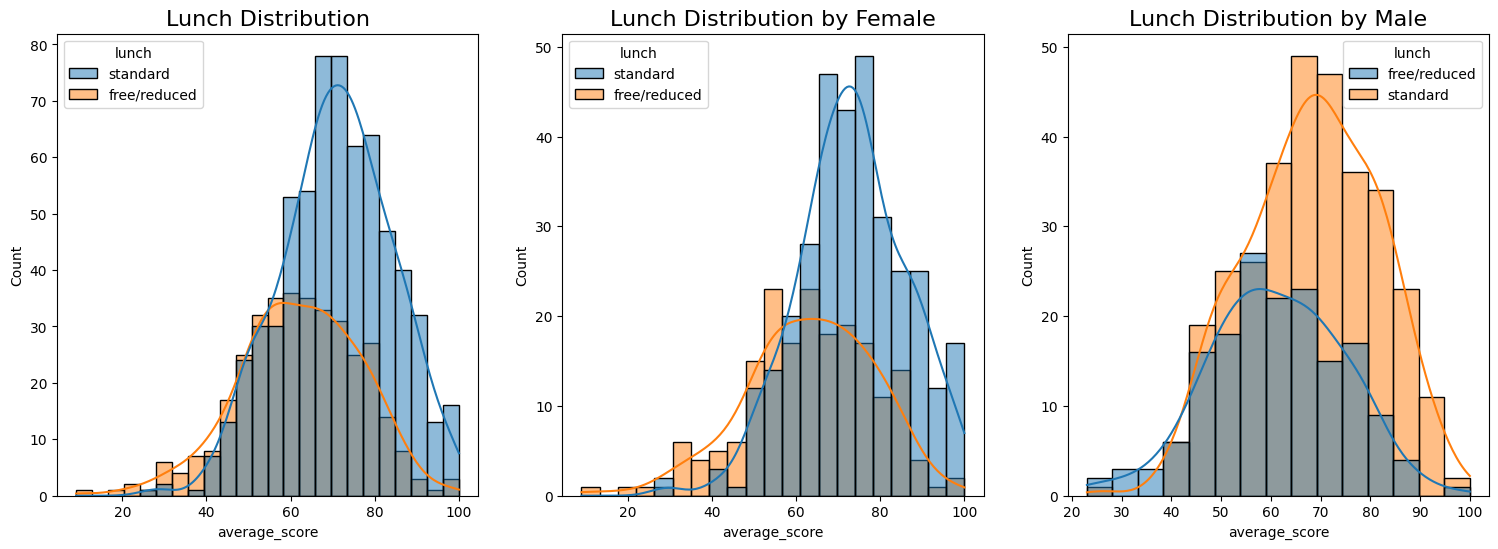

In [43]:
fig, axs = plt.subplots(1, 3, figsize=(25, 6))
plt.subplot(141)
plt.title('Lunch Distribution', size=16)
sns.histplot(data=df, x='average_score', kde=True, hue='lunch')
plt.subplot(142)
plt.title('Lunch Distribution by Female', size=16)
sns.histplot(data=df[df['gender']=='female'], x='average_score', kde=True, hue='lunch') # type: ignore
plt.subplot(143)
plt.title('Lunch Distribution by Male', size=16)
sns.histplot(data=df[df['gender']=='male'], x='average_score', kde=True, hue='lunch') # type: ignore
plt.show()

> Standard lunch helps Perform better in Exams.